In [2]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
import numpy as np

model = joblib.load("../models/fraud_xgb_model.pkl")
X_test = pd.read_csv("../data/X_test.csv")

print("Model loaded successfully")
print("X_test shape:", X_test.shape)

Model loaded successfully
X_test shape: (56962, 30)


In [3]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("SHAP values generated")

SHAP values generated


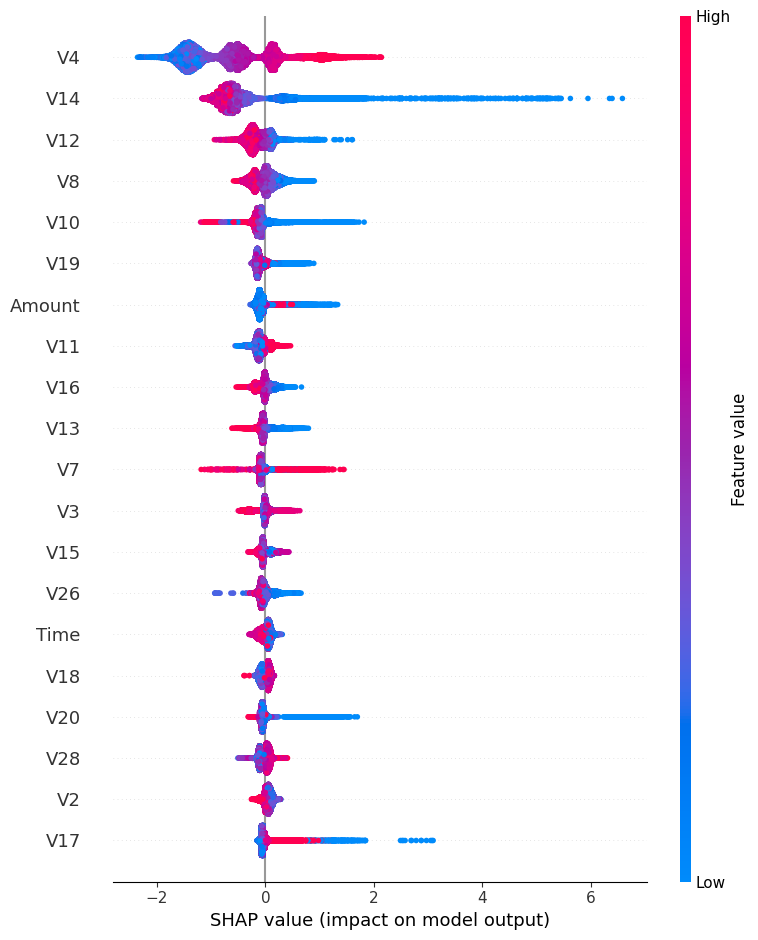

In [4]:
shap.summary_plot(shap_values, X_test)

In [5]:
def get_top_reasons(row_index, top_n=5):
    values = shap_values[row_index]
    feature_names = X_test.columns

    top_indices = np.argsort(np.abs(values))[-top_n:][::-1]

    reasons = []
    for i in top_indices:
        reasons.append({
            "feature": feature_names[i],
            "shap_value": float(values[i]),
            "feature_value": float(X_test.iloc[row_index, i])
        })

    return reasons

get_top_reasons(0)

[{'feature': 'V4',
  'shap_value': -1.4858269691467285,
  'feature_value': -1.32836577843066},
 {'feature': 'V14',
  'shap_value': -0.40460145473480225,
  'feature_value': 0.266371326329879},
 {'feature': 'V8',
  'shap_value': 0.27061498165130615,
  'feature_value': -0.614232966299775},
 {'feature': 'V7',
  'shap_value': 0.2686415910720825,
  'feature_value': 1.88587890268717},
 {'feature': 'V10',
  'shap_value': -0.23976051807403564,
  'feature_value': 0.65075700363522}]

In [6]:
print("Top reasons for transaction 0:")
print(get_top_reasons(0))

print("\nTop reasons for transaction 10:")
print(get_top_reasons(10))

print("\nTop reasons for transaction 50:")
print(get_top_reasons(50))

Top reasons for transaction 0:
[{'feature': 'V4', 'shap_value': -1.4858269691467285, 'feature_value': -1.32836577843066}, {'feature': 'V14', 'shap_value': -0.40460145473480225, 'feature_value': 0.266371326329879}, {'feature': 'V8', 'shap_value': 0.27061498165130615, 'feature_value': -0.614232966299775}, {'feature': 'V7', 'shap_value': 0.2686415910720825, 'feature_value': 1.88587890268717}, {'feature': 'V10', 'shap_value': -0.23976051807403564, 'feature_value': 0.65075700363522}]

Top reasons for transaction 10:
[{'feature': 'V14', 'shap_value': -0.7849341630935669, 'feature_value': 1.25703516939234}, {'feature': 'V10', 'shap_value': 0.7225485444068909, 'feature_value': -3.25169880153788}, {'feature': 'V12', 'shap_value': -0.48053061962127686, 'feature_value': 2.05674468195772}, {'feature': 'V22', 'shap_value': 0.4199877679347992, 'feature_value': 1.87646718588776}, {'feature': 'V8', 'shap_value': 0.36790934205055237, 'feature_value': -10.5198637587747}]

Top reasons for transaction 50: